In [1]:
import os
import json
import gzip
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import random
from collections import defaultdict
from tqdm import tqdm
random.seed(2024)

In [2]:
# Extract Data (only save the shared data between two jsons)
id_to_title_map = {}
asin_set = []
with gzip.open('./raw_data/meta_Video_Games.json.gz', 'r') as file:
    for line in file:
        data = json.loads(line)
        if "asin" in data:
            asin_set.append(data['asin'])
asin_set = set(asin_set)

inter_dict = {}
with gzip.open('./raw_data/Video_Games_5.json.gz', 'r') as file:
    for line in file:
        review = json.loads(line)
        if review['overall'] < 0 or review['asin'] not in asin_set or "reviewerName" not in review:
            continue
        u_id, i_id, time = review['reviewerID'], review['asin'], review['unixReviewTime']
        if u_id not in inter_dict:
            inter_dict[u_id] = {}
        inter_dict[u_id][i_id] = time
print('raw user num:',len(inter_dict))

raw user num: 55212


In [3]:
def select_kcore(interaction_dict, user_K, item_K):
    flag = 0
    while flag == 0:
        item_cnt_dict = {}
        item_drop_dict = {}

        # create item_drop_dict, item_cnt_dict
        for user_id in interaction_dict:
            for item_id, time in interaction_dict[user_id].items():
                if item_id not in item_cnt_dict:
                    item_cnt_dict[item_id] = 0
                    item_drop_dict[item_id] = 0
                item_cnt_dict[item_id] += 1

        assert len(item_drop_dict)==len(item_cnt_dict)

        # delete items < K
        del_iid_list = []
        for i_id in item_cnt_dict:
            if item_cnt_dict[i_id] < item_K:
                del_iid_list.append(i_id)

        for i_id in del_iid_list:
            item_drop_dict[i_id] = 1
        for u_id in interaction_dict:
            del_id_list = []
            for i_id, _ in interaction_dict[u_id].items():
                if item_drop_dict[i_id]:
                    del_id_list.append(i_id)
            for del_id in del_id_list:
                del interaction_dict[u_id][del_id]

        item_drop_num = 0
        for i_id in item_drop_dict:
            item_drop_num += item_drop_dict[i_id]
        item_num = len(item_drop_dict) - item_drop_num
        #print(f'item num after item-{K}core:',item_num)

        new_item_cnt = {}
        min_cnt = 999
        for u_id in interaction_dict:
            min_cnt = min(min_cnt, len(interaction_dict[u_id]))
            for i_id, _ in interaction_dict[u_id].items():
                if i_id not in new_item_cnt:
                    new_item_cnt[i_id] = 0
                new_item_cnt[i_id] += 1

        min_cnt_item = 999
        for i_id in new_item_cnt:
            min_cnt_item = min(min_cnt_item, new_item_cnt[i_id])
        #print('min item num:',min_cnt_item)
        if min_cnt >= user_K and min_cnt_item >= item_K:
            return interaction_dict, len(interaction_dict), item_num
        
        # delete users interactions < K
        del_uid_list = []
        for u_id in interaction_dict:
            if len(interaction_dict[u_id]) < user_K:
                del_uid_list.append(u_id)
        for u_id in del_uid_list:
            del interaction_dict[u_id]
        
        # count min user-interaction and item appearance
        new_item_cnt = {}
        min_cnt = 999
        for u_id in interaction_dict:
            min_cnt = min(min_cnt, len(interaction_dict[u_id]))
            for i_id, _ in interaction_dict[u_id].items():
                if i_id not in new_item_cnt:
                    new_item_cnt[i_id] = 0
                new_item_cnt[i_id] += 1

        min_cnt_item = 999
        for i_id in new_item_cnt:
            min_cnt_item = min(min_cnt_item, new_item_cnt[i_id])     
        if min_cnt >= user_K and min_cnt_item >= item_K:
            return interaction_dict, len(interaction_dict), item_num

interaction_dict, user_num, item_num = select_kcore(inter_dict, 5, 5)
print('uesr num after k core',user_num)
print('item num after k core',item_num)
inter_num = 0
for u_id in interaction_dict:
    inter_num += len(interaction_dict[u_id])
density = inter_num / (user_num * item_num)
print(f'interaction number: {inter_num}')
print(f'density: {density}')

for u_id in interaction_dict:
    interaction_dict[u_id] = dict(sorted(interaction_dict[u_id].items(),key=lambda item:item[1]))
    
for u_id in interaction_dict:
    print(interaction_dict[u_id])
    break

uesr num after k core 50532
item num after k core 16857
interaction number: 452894
density: 0.0005316793498231202
{'B00737H0KQ': 1388102400, 'B00L4KVO78': 1397520000, 'B000B8J7K0': 1408147200, 'B0000ALFCI': 1410048000, 'B00178630A': 1423094400, '0700026657': 1445040000, 'B0009VXBAQ': 1445040000, 'B000FQ9QVI': 1445040000, 'B000P5BSUQ': 1445040000, 'B0018QOWEU': 1445040000, 'B0019R4VCQ': 1445040000, 'B00282WKEW': 1445040000, 'B002AB7TX8': 1445040000, 'B002BXKJA0': 1445040000, 'B002GEKIOG': 1445040000, 'B003YLWJLA': 1445040000, 'B004X56PWK': 1445040000, 'B0053B5RGI': 1445040000, 'B005EYRAUK': 1445040000, 'B005EZ5GNW': 1445040000, 'B006JKASAC': 1445040000, 'B00AYABWYE': 1445040000, 'B00CH923NE': 1445040000, 'B00000JMWB': 1445040000, 'B0019R3O7E': 1445040000, 'B001L1RZ32': 1445040000}


In [4]:
# mapping user and item id
item_list = []
user_mapping = {key: i for i, key in enumerate(interaction_dict.keys())}
for u_id in interaction_dict:
    for i_id in interaction_dict[u_id]:
        item_list.append(i_id)
item_set = list(set(item_list))
random.shuffle(item_set)
item_mapping = {value: i for i, value in enumerate(item_set)}

train time interval:939859200-1463184000
valid time interval:1463184000-1484870400
test time interval:1484870400-1538438400


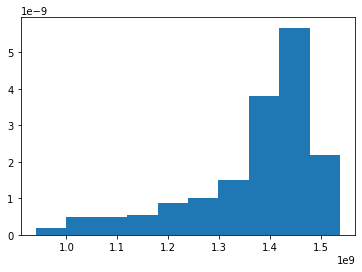

In [5]:
# split the dataset following global split
time_list = []
for u_id in interaction_dict:
    for i_id in interaction_dict[u_id]:
        time_list.append(interaction_dict[u_id][i_id])
time_list = sorted(time_list)
plt.hist(time_list,density=True)

test_ratio = 0.1
test_num = int(0.1*len(time_list))
time_list = sorted(time_list)
print(f'train time interval:{time_list[0]}-{time_list[int(-2*test_num)]}')
print(f'valid time interval:{time_list[int(-2*test_num)]}-{time_list[-test_num]}')
print(f'test time interval:{time_list[-test_num]}-{time_list[-1]}')

train_interval = [time_list[0], time_list[int(-2*test_num)]]
valid_interval = [time_list[int(-2*test_num)], time_list[-test_num]]
test_interval = [time_list[-test_num],time_list[-1]]

def time2set(t):
    if t<train_interval[1]:
        return 0
    elif t<valid_interval[1]:
        return 1
    else:
        return 2

train_dict, valid_dict, test_dict = {}, {}, {}
for u_id in interaction_dict:
    for i_id, time in interaction_dict[u_id].items():
        split_set = time2set(time)
        if split_set == 0:
            if user_mapping[u_id] not in train_dict:
                train_dict[user_mapping[u_id]] = []
            train_dict[user_mapping[u_id]].append(item_mapping[i_id])
        elif split_set == 1:
            if user_mapping[u_id] not in valid_dict:
                valid_dict[user_mapping[u_id]] = []
            valid_dict[user_mapping[u_id]].append(item_mapping[i_id])
        else:
            if user_mapping[u_id] not in test_dict:
                test_dict[user_mapping[u_id]] = []
            test_dict[user_mapping[u_id]].append(item_mapping[i_id])

In [6]:
def remove_cold_users_items_iteratively(train, valid, test, user_map, item_map):
    """
    Iteratively remove cold users and items and remap user and item IDs.

    Args:
    - train (dict): Training data, where key is user ID and value is list of item IDs.
    - valid (dict): Validation data, similar to train.
    - test (dict): Test data, similar to train.
    - min_interactions (int): Minimum number of interactions for a user or item to be kept.

    Returns:
    - dict: New train, valid, test datasets with remapped user and item IDs.
    """
    from collections import defaultdict

    def get_cold_user_item(train, valid, test):
        drop_user, drop_item = [], []

        for u_id in valid:
            if u_id not in train:
                drop_user.append(u_id)
        for u_id in test:
            if u_id not in train:
                drop_user.append(u_id)

        item_set = set()
        for u_id in train:
            if len(train[u_id]) < 2:
                drop_user.append(u_id)
            for i_id in train[u_id]:
                item_set.add(i_id)
        for u_id in valid:
            for i_id in valid[u_id]:
                if i_id not in item_set:
                    drop_item.append(i_id)
        for u_id in test:
            for i_id in test[u_id]:
                if i_id not in item_set:
                    drop_item.append(i_id)

        drop_user = list(set(drop_user))
        drop_item = list(set(drop_item))
        return [], []

    def get_all_interaction(train, valid, test):
        user_set, item_set = set(), set()
        for u_id in train:
            user_set.add(u_id)
            for i_id in train[u_id]:
                item_set.add(i_id)
        for u_id in valid:
            user_set.add(u_id)
            for i_id in valid[u_id]:
                item_set.add(i_id)
        for u_id in test:
            user_set.add(u_id)
            for i_id in test[u_id]:
                item_set.add(i_id)
        return list(user_set), list(item_set)

    def remap_ids(all_list, drop_list):
        drop_set = set(drop_list)

        # Remove elements present in drop_list
        remaining_elements = [element for element in all_list if element not in drop_set]

        # Remap remaining elements
        unique_elements = sorted(set(remaining_elements))  # Get unique elements and sort
        remap_dict = {element: new_id for new_id, element in enumerate(unique_elements)}

        return remap_dict

    def remap_dataset(dataset, user_id_map, item_id_map):
        new_dataset = {}
        for user, items in dataset.items():
            if user in user_id_map:
                new_items = [item_id_map[item] for item in items if item in item_id_map]
                if new_items:
                    new_dataset[user_id_map[user]] = new_items
        return new_dataset

    def map_update(id_map, semantic_map):
        # id_map: key:old id; value:new id
        # semantic_map: key:asin; value: old id
        # what I want: key:asin, value: new id
        new_map = {}
        for asin in semantic_map:
            if semantic_map[asin] in id_map:
                new_map[asin] = id_map[semantic_map[asin]]
        return new_map
    
    # Iteratively remove cold users and items
    cnt = 0
    while True:
        cold_user, cold_item = get_cold_user_item(train, valid, test)
        user_set, item_set = get_all_interaction(train, valid, test)
        if cnt == 0:
            new_user_map = user_map
            new_item_map = item_map

        if not cold_user and not cold_item:
            print(cnt)
            break  # No more cold users or items

        user_id_map = remap_ids(user_set, cold_user)
        item_id_map = remap_ids(item_set, cold_item)
        
        new_user_map = map_update(user_id_map, new_user_map)
        new_item_map = map_update(item_id_map, new_item_map)

        train = remap_dataset(train, user_id_map, item_id_map)
        valid = remap_dataset(valid, user_id_map, item_id_map)
        test = remap_dataset(test, user_id_map, item_id_map)

        cnt += 1
    return train, valid, test, new_user_map, new_item_map

new_train, new_valid, new_test, new_user_mapping, new_item_mapping = remove_cold_users_items_iteratively(train_dict, valid_dict, test_dict, user_mapping, item_mapping)
train_list, valid_list, test_list = [], [], []
for u_id in new_train:
    for i_id in new_train[u_id]:
        train_list.append([u_id, i_id])
for u_id in new_valid:
    for i_id in new_valid[u_id]:
        valid_list.append([u_id, i_id])
for u_id in new_test:
    for i_id in new_test[u_id]:
        test_list.append([u_id, i_id])

0


In [7]:
# save data
save_path = './'

np.save(save_path + 'train_list.npy', np.array(train_list))
np.save(save_path + 'valid_list.npy', np.array(valid_list))
np.save(save_path + 'test_list.npy', np.array(test_list))

np.save(save_path + 'training_dict.npy', new_train)
np.save(save_path + 'validation_dict.npy', new_valid)
np.save(save_path + 'testing_dict.npy', new_test)

In [8]:
# Statistical Information
train_dict, valid_dict, test_dict = new_train, new_valid, new_test
print(f'User number: {len(train_dict)}')
item_list = []
inter_num = 0
for u_id in train_dict:
    item_list.extend(train_dict[u_id])
    inter_num += len(train_dict[u_id])
for u_id in valid_dict:
    inter_num += len(valid_dict[u_id])
for u_id in test_dict:
    inter_num += len(test_dict[u_id])
item_list = list(set(item_list))
print(f'Item number: {len(item_list)}')
print(f'Inter num: {inter_num}')
density = inter_num / (user_num * item_num)
print(f'density: {density}')

User number: 45817
Item number: 16132
Inter num: 452894
density: 0.0005316793498231202


In [9]:
# update sequential interactions
# update train
train_interactions = []
cnt = 0
for u_id in train_dict:
    for i in range(min(10, len(train_dict[u_id]) - 1), len(train_dict[u_id])):
        st = max(i-10, 0)
        history_item = [item for item in train_dict[u_id][st:i]]
        if history_item == []:
            cnt += 1
            continue
        train_interactions.append([u_id, history_item, train_dict[u_id][i]])
print(f'empty history item: {cnt}')
        
# update valid
valid_interactions = []
for u_id in valid_dict:
    for cnt, i in enumerate(valid_dict[u_id]):
        if u_id not in train_dict:
            continue
        else:
            if cnt == 0:
                history_item = train_dict[u_id][-10:]
            elif cnt < 10:
                history_item = train_dict[u_id][-10+cnt:] + valid_dict[u_id][:cnt]
            else:
                history_item = valid_dict[u_id][cnt-10:cnt]
        valid_interactions.append([u_id, history_item, valid_dict[u_id][cnt]])

# update test
test_interactions = []
for u_id in test_dict:
    if u_id in valid_dict and u_id in train_dict:
        train_valid_item = train_dict[u_id] + valid_dict[u_id]
    elif u_id in valid_dict:
        train_valid_item = valid_dict[u_id]
    elif u_id in train_dict:
        train_valid_item = train_dict[u_id]
    else:
        continue
    history_item = train_valid_item[-10:]
    test_interactions.append([u_id, history_item, test_dict[u_id]])

print(len(train_interactions))
print(len(valid_interactions))
print(len(test_interactions))

empty history item: 1530
110404
29877
11936


In [10]:
# get the item id to title map
save_path = './'
id_to_title_map = {}
with gzip.open('./raw_data/meta_Video_Games.json.gz', 'r') as file:
    for line in file:
        data = json.loads(line)
        if "asin" in data:
            id_to_title_map[data['asin']] = data['title']
integer_to_title_map = {}
for asin, id in new_item_mapping.items():
    integer_to_title_map[id] = id_to_title_map[asin]

np.save(save_path + 'id_to_title_map.npy', integer_to_title_map)
np.save(save_path + 'asin_to_id_map.npy', new_item_mapping)
np.save(save_path + 'userasin_to_id_map.npy', new_user_mapping)
# Get the user id to name map
id_to_name_map = {}
with gzip.open('./raw_data/Video_Games_5.json.gz', 'r') as file:
    for line in file:
        data = json.loads(line)
        if "reviewerID" in data and "reviewerName" in data:
            id_to_name_map[data['reviewerID']] = data['reviewerName']
integer_to_name_map = {}
for reviewid, uid in new_user_mapping.items():
    integer_to_name_map[uid] = id_to_name_map[reviewid]

np.save('./id_to_name_map.npy', integer_to_name_map)

In [11]:
def csv_to_json_test(interactions, output_path, sample=False):
    json_list = []
    for user, history_item, target_item in interactions:
        history = "The user has played the following video games before:"
        for i in range(len(history_item)):
            if i == 0:
                history += "\"" + integer_to_title_map[history_item[i]] + "\""
            else:
                history += ", \"" + integer_to_title_map[history_item[i]] + "\""
        for i in range(len(target_item)):
            if i == 0:
                target_movie = "\"" + integer_to_title_map[target_item[i]] + "\""
            else:
                target_movie += ", \"" + integer_to_title_map[target_item[i]] + "\""
        json_list.append({
            "instruction": "Given a list of video games the user has played before, please recommend a new video game that the user likes to the user.",
            "input": f"{history}\n ",
            "output": target_movie,
        })  
    if sample == True:
        json_list = random.sample(json_list, 1024)
    
    with open(output_path, 'w') as f:
        json.dump(json_list, f, indent=4)

def csv_to_json_test_user(interactions, output_path, sample=False):
    json_list = []
    for user, history_item, target_item in interactions:
        history = "The user has played the following video games before:"
        for i in range(len(history_item)):
            if i == 0:
                history += "\"" + integer_to_title_map[history_item[i]] + "\""
            else:
                history += ", \"" + integer_to_title_map[history_item[i]] + "\""
        for i in range(len(target_item)):
            if i == 0:
                target_movie = "\"" + integer_to_title_map[target_item[i]] + "\""
            else:
                target_movie += ", \"" + integer_to_title_map[target_item[i]] + "\""
        json_list.append({
            "instruction": "Given a list of video games the user has played before, please recommend a new video game that the user likes to the user.",
            "input": f"{history}\n ",
            "output": target_movie,
            "user": user,
        })  
    if sample == True:
        json_list = random.sample(json_list, 1024)
    
    with open(output_path, 'w') as f:
        json.dump(json_list, f, indent=4)

def csv_to_json(interactions, output_path, output_user_path, sample_num, sample=False):
    json_list = []
    for user, history_item, target_item in interactions:
        history = "The user has played the following video games before:"
        for i in range(len(history_item)):
            if i == 0:
                history += "\"" + integer_to_title_map[history_item[i]] + "\""
            else:
                history += ", \"" + integer_to_title_map[history_item[i]] + "\""
        target_movie = integer_to_title_map[target_item]
        target_movie_str = "\"" + target_movie + "\""

        json_list.append({
            "instruction": "Given a list of video games the user has played before, please recommend a new video game that the user likes to the user.",
            "input": f"{history}\n ",
            "output": target_movie_str,
            "user": user,
        })  
    if sample == True:
        json_list = random.sample(json_list, sample_num)
    
    json_list_without_user = []
    for item in json_list:
        json_list_without_user.append({
            "instruction": "Given a list of video games the user has played before, please recommend a new video game that the user likes to the user.",
            "input": item["input"],
            "output": item["output"],
        })

    with open(output_path, 'w') as f:
        json.dump(json_list_without_user, f, indent=4)
    with open(output_user_path, 'w') as f:
        json.dump(json_list, f, indent=4)
csv_to_json(train_interactions, './train.json','./train_user.json',  0)
csv_to_json(train_interactions, './train_1024.json', './train_1024_user.json', 1024, sample=True)
csv_to_json(train_interactions, './train_2048.json', './train_2048_user.json', 2048, sample=True)
csv_to_json(train_interactions, './train_4096.json', './train_4096_user.json', 4096, sample=True)
csv_to_json(valid_interactions, './valid.json', './valid_user.json', 0)
csv_to_json(valid_interactions, './valid_5000.json', './valid_5000_user.json', 5000, sample=True)
csv_to_json_test(test_interactions, './test.json')
csv_to_json_test_user(test_interactions, './test_user.json')
# csv_to_json(train_interactions, './train_1024_user.json', 1024, sample=True, with_user=True)

In [12]:
# get train, valid, test dict for TIGER
with open('train_interactions.json', 'w') as file:
    json.dump(train_interactions, file)
    

In [13]:
with open('test_interactions.json', 'w') as file:
    json.dump(test_interactions, file)

with open('valid_interactions.json', 'w') as file:
    json.dump(valid_interactions, file)